In [1]:
from google.cloud import bigquery
import pandas as pd

In [2]:
# client = bigquery.Client()

In [3]:
# query = """
# SELECT *
# FROM `gridzero-489711.gridzero.carbon_intensity_2025`
# LIMIT 1000
# """

# df = client.query(query).to_dataframe()

# print(df.head())

In [4]:
# client = bigquery.Client()

# table_id = 'gridzero-489711.gridzero.carbon_intensity_2025'

# table = client.get_table(table_id)
# rows = client.list_rows(table)

# df = rows.to_dataframe()

# Carbon Intensity Data

In [5]:
PROJECT = "gridzero-489711"
DATASET = "gridzero"
TABLE = "carbon_intensity_2025"

query = f"""       
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
    """

client = bigquery.Client(project='gridzero-489711')
query_job = client.query(query)
result = query_job.result()
df = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [6]:
df

,timestamp,carbon_intensity
0,2025-05-29 11:00:00+00:00,24
1,2025-05-29 08:30:00+00:00,25
2,2025-05-29 09:00:00+00:00,25
3,2025-05-29 09:30:00+00:00,25
4,2025-05-29 10:00:00+00:00,25
...,...,...
17467,2025-01-20 06:00:00+00:00,285
17468,2025-01-22 05:30:00+00:00,290
17469,2025-01-22 07:00:00+00:00,291
17470,2025-01-22 06:00:00+00:00,293


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

/var/folders/0s/rkp2dnc532q3ycyt389hy7f00000gn/T/ipykernel_72848/3805534081.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


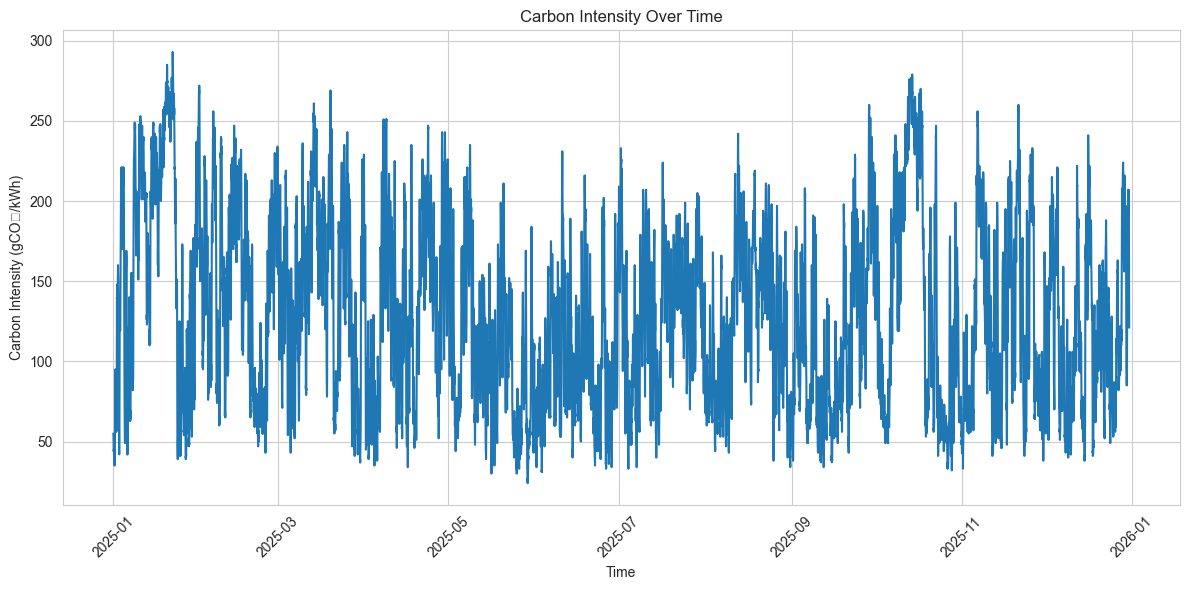

In [8]:
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="carbon_intensity"
)

plt.title("Carbon Intensity Over Time")
plt.xlabel("Time")
plt.ylabel("Carbon Intensity (gCO₂/kWh)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


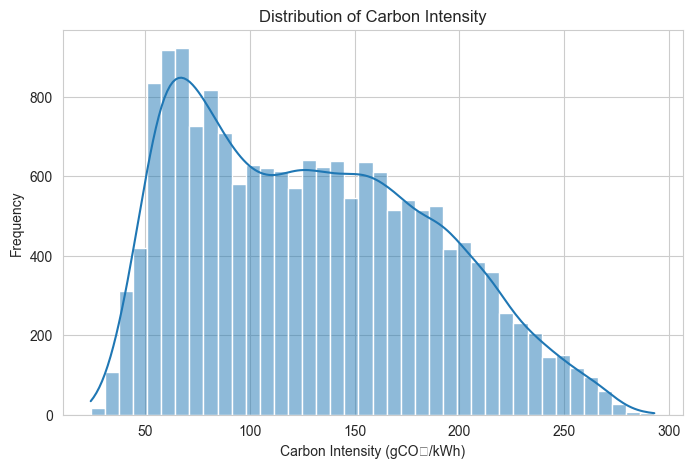

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["carbon_intensity"],
    bins=40,
    kde=True
)

plt.title("Distribution of Carbon Intensity")
plt.xlabel("Carbon Intensity (gCO₂/kWh)")
plt.ylabel("Frequency")

plt.show()

/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


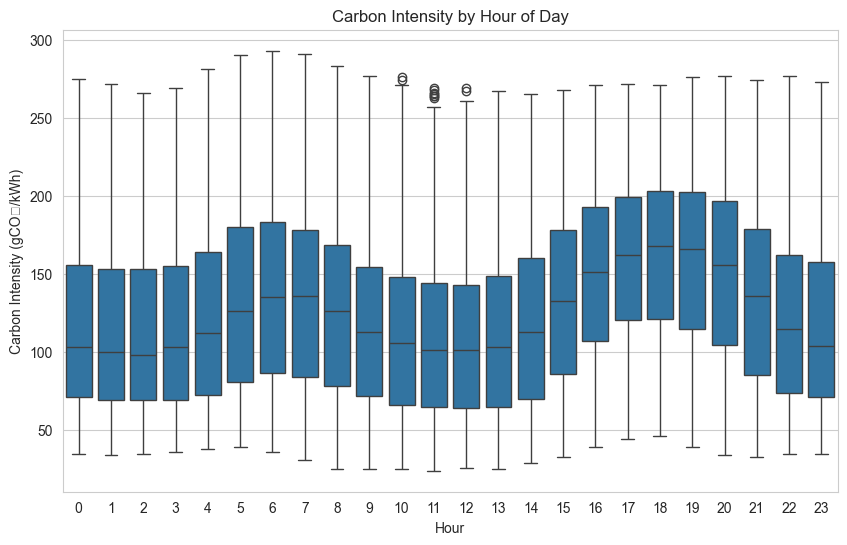

In [10]:
df["hour"] = df["timestamp"].dt.hour

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="hour",
    y="carbon_intensity"
)

plt.title("Carbon Intensity by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Carbon Intensity (gCO₂/kWh)")

plt.show()

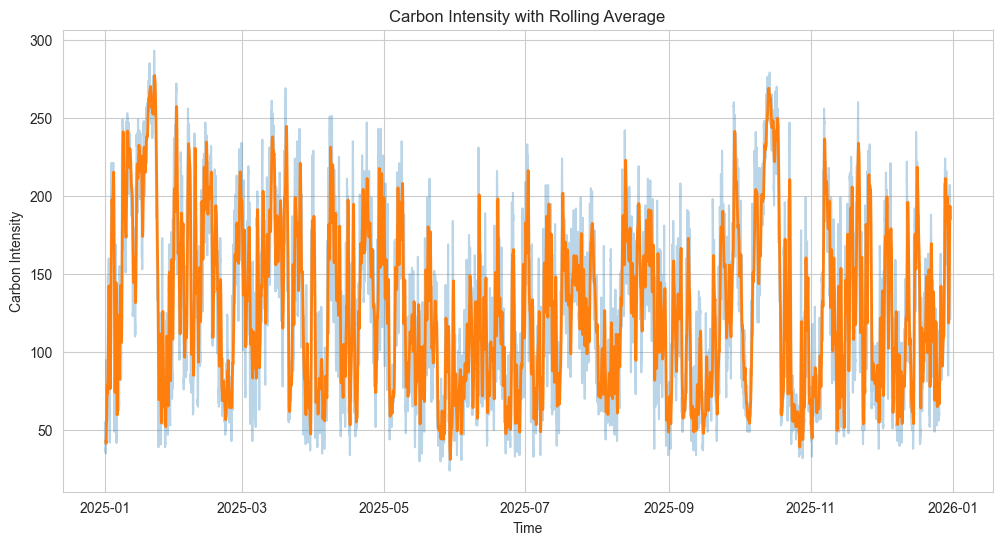

In [11]:
df = df.sort_values("timestamp")
df["rolling_avg"] = df["carbon_intensity"].rolling(24).mean()

plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="timestamp", y="carbon_intensity", alpha=0.3)
sns.lineplot(data=df, x="timestamp", y="rolling_avg", linewidth=2)

plt.title("Carbon Intensity with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Carbon Intensity")

plt.show()

# Exelon Data

In [12]:
PROJECT = "gridzero-489711"
DATASET = "Exelon_Generation_Mix"
TABLE = "Exelon_Generation_AGBT_2025"

query = f"""       
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
    """

client = bigquery.Client(project='gridzero-489711')
query_job = client.query(query)
result = query_job.result()
df2 = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [13]:
df2

,StartTime,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW
0,2025-05-11 14:00:00+00:00,1132.0,3072.0,0.0,0.0,85.0,44.0,3939.0,705.0,8437.0,5391.524,1910.760,24716.284
1,2025-06-24 12:00:00+00:00,1145.0,1815.0,0.0,0.0,5.0,44.0,4798.0,581.0,7390.0,9573.137,6128.941,31480.078
2,2025-04-08 14:00:00+00:00,2082.0,8899.0,0.0,0.0,95.0,45.0,4539.0,279.0,9323.0,701.796,453.660,26417.456
3,2025-04-09 12:30:00+00:00,2538.0,7468.0,0.0,0.0,23.0,45.0,4448.0,289.0,9804.0,2508.407,1123.173,28246.580
4,2025-04-22 00:00:00+00:00,1758.0,10191.0,0.0,0.0,73.0,45.0,3777.0,137.0,0.0,1680.580,1477.749,19139.329
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17471,2025-12-11 21:30:00+00:00,3100.0,10761.0,0.0,0.0,300.0,1010.0,3516.0,333.0,0.0,9755.629,6110.086,34885.715
17472,2025-02-15 09:00:00+00:00,6060.0,33812.0,0.0,0.0,300.0,1028.0,8622.0,926.0,1147.0,8224.254,2474.817,62594.071
17473,2025-01-03 22:30:00+00:00,2279.0,15724.0,0.0,0.0,300.0,1106.0,5031.0,191.0,0.0,2592.917,838.505,28062.422
17474,2025-01-03 22:00:00+00:00,2275.0,17284.0,0.0,0.0,300.0,1107.0,5034.0,247.0,0.0,2848.918,808.608,29904.526


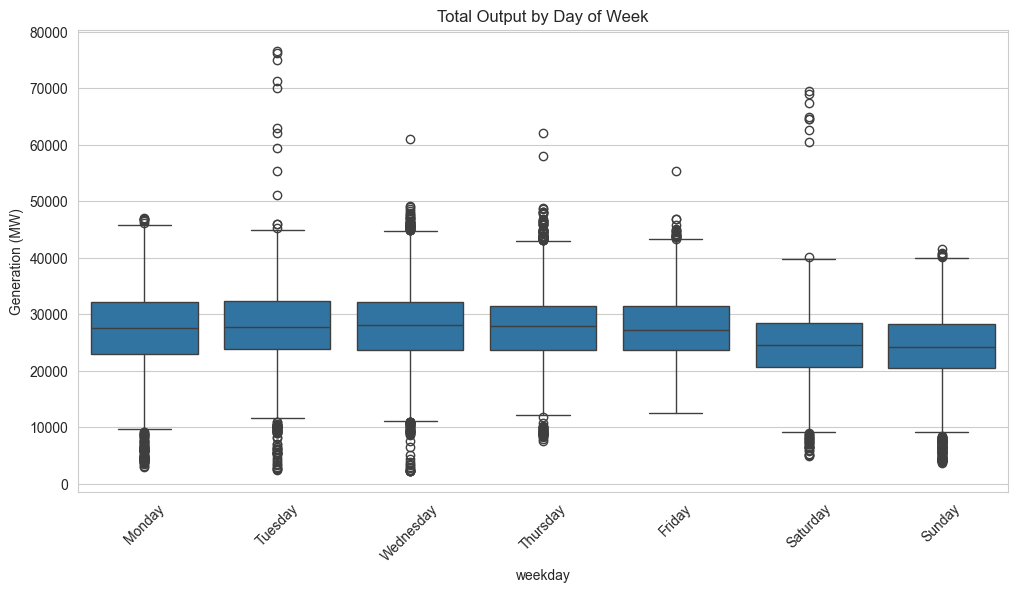

In [16]:
df2["weekday"] = df2["StartTime"].dt.day_name()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df2,
    x="weekday",
    y="TotalOutput-MW",
    order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

plt.title("Total Output by Day of Week")
plt.ylabel("Generation (MW)")
plt.xticks(rotation=45)

plt.show()

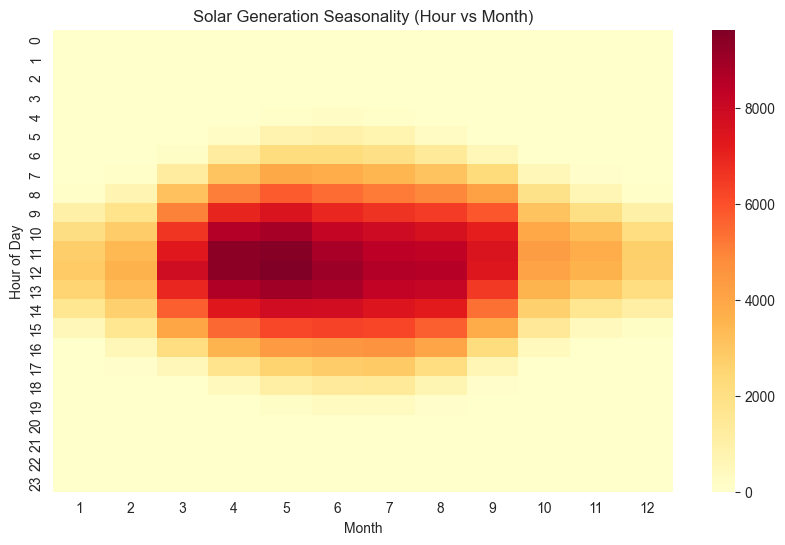

In [17]:
df2["hour"] = df2["StartTime"].dt.hour
df2["month"] = df2["StartTime"].dt.month

pivot = df2.pivot_table(
    values="Solar",
    index="hour",
    columns="month",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    cmap="YlOrRd"
)

plt.title("Solar Generation Seasonality (Hour vs Month)")
plt.xlabel("Month")
plt.ylabel("Hour of Day")

plt.show()

In [25]:
# PROJECT = "gridzero-489711"
# DATASET = "Exelon_Generation_Mix"
# TABLE = "Exelon_Generation_AGBT_2025"

# query = f"""       
#     SELECT *
#     FROM {PROJECT}.{DATASET}.{TABLE}
#     """

# client = bigquery.Client(project='gridzero-489711')
# query_job = client.query(query)
# result = query_job.result()
# df2 = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [28]:
df2["StartTime"] = pd.to_datetime(df2["StartTime"])
df2 = df2.set_index("StartTime")

df_hourly = df2.resample("1H").mean().reset_index()

/var/folders/0s/rkp2dnc532q3ycyt389hy7f00000gn/T/ipykernel_72848/1875975289.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df2.resample("1H").mean().reset_index()


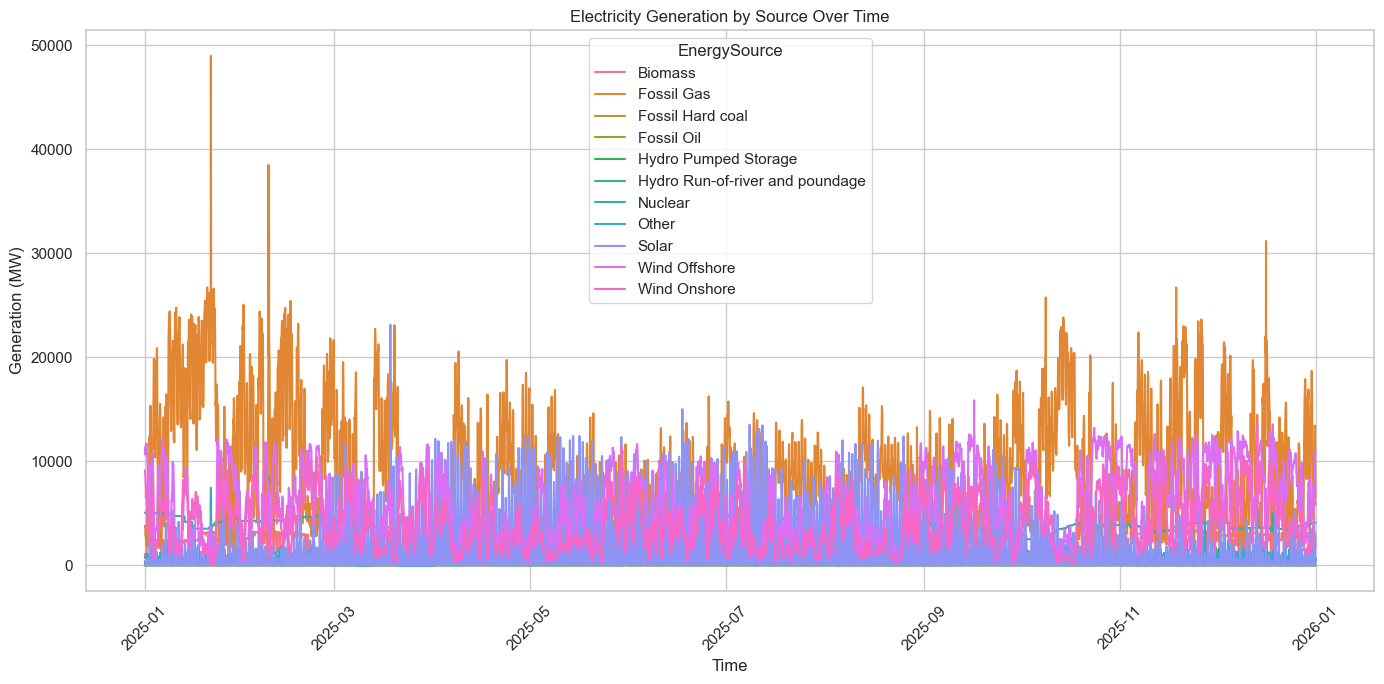

In [29]:
sns.set_theme(style="whitegrid")

energy_cols = [
    "Biomass", "Fossil Gas", "Fossil Hard coal", "Fossil Oil",
    "Hydro Pumped Storage", "Hydro Run-of-river and poundage",
    "Nuclear", "Other", "Solar", "Wind Offshore", "Wind Onshore"
]

df_long = df_hourly.melt(
    id_vars="StartTime",
    value_vars=energy_cols,
    var_name="EnergySource",
    value_name="MW"
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=df_long,
    x="StartTime",
    y="MW",
    hue="EnergySource"
)

plt.title("Electricity Generation by Source Over Time")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
df_long

,StartTime,EnergySource,MW
0,2024-12-31 23:00:00+00:00,Biomass,771.0000
1,2025-01-01 00:00:00+00:00,Biomass,979.0000
2,2025-01-01 01:00:00+00:00,Biomass,1106.5000
3,2025-01-01 02:00:00+00:00,Biomass,981.0000
4,2025-01-01 03:00:00+00:00,Biomass,784.5000
...,...,...,...
96355,2025-12-31 18:00:00+00:00,Wind Onshore,6709.2380
96356,2025-12-31 19:00:00+00:00,Wind Onshore,6209.9970
96357,2025-12-31 20:00:00+00:00,Wind Onshore,5764.8595
96358,2025-12-31 21:00:00+00:00,Wind Onshore,5824.2590


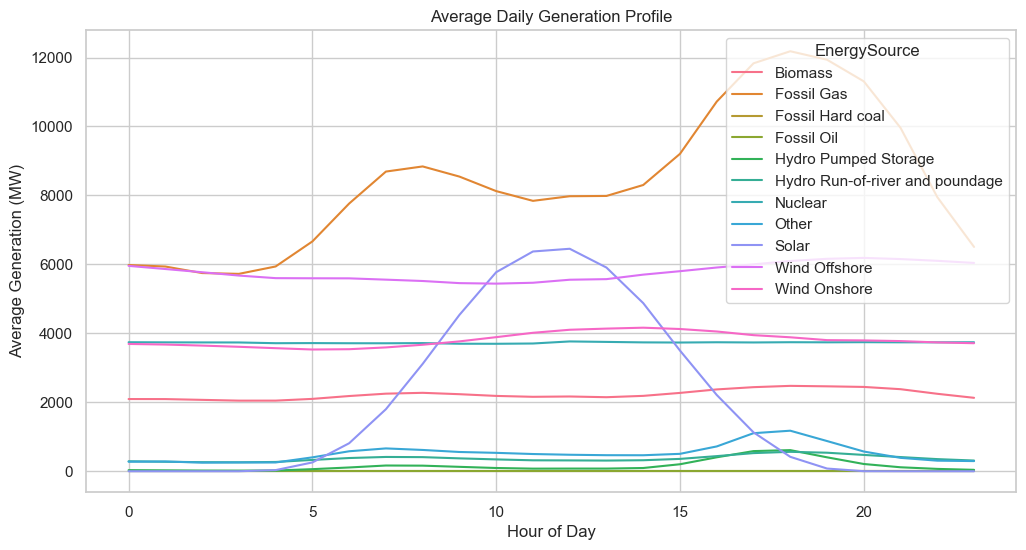

In [32]:
df2["hour"] = df2.index.hour

daily_profile = df2.groupby("hour")[energy_cols].mean().reset_index()

df_profile_long = daily_profile.melt(
    id_vars="hour",
    value_vars=energy_cols,
    var_name="EnergySource",
    value_name="MW"
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_profile_long,
    x="hour",
    y="MW",
    hue="EnergySource"
)

plt.title("Average Daily Generation Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Average Generation (MW)")

plt.show()